## **Defi 1**

In [182]:
import numpy as np
from scipy.stats import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [183]:
df_airplane = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')

In [184]:
df_airplane.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [185]:
df_airplane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

In [186]:
df_airplane.isnull().sum()

Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
dtype: int64

In [187]:
df_airplane = df_airplane[df_airplane['Location'].notna()]
df_airplane = df_airplane[df_airplane['Operator'].notna()]
df_airplane = df_airplane[df_airplane['Fatalities'].notna()]
df_airplane = df_airplane[df_airplane['Aboard'].notna()]
df_airplane = df_airplane[df_airplane['AC Type'].notna()]
df_airplane = df_airplane[df_airplane['Ground'].notna()]
df_airplane = df_airplane[df_airplane['Summary'].notna()]

In [188]:
df_airplane.isnull().sum()

Date                        0
Time                     1408
Location                    0
Operator                    0
Flight #                 3549
Route                     702
AC Type                     0
Registration              229
cn/ln                     594
Aboard                      0
Aboard Passangers         174
Aboard Crew               171
Fatalities                  0
Fatalities Passangers     189
Fatalities Crew           187
Ground                      0
Summary                     0
dtype: int64

Ces données supprimer, représentait moins de 1% de notre dataset global, donc négligeable. Alors lors nous avons préféré les supprimer les données manquantes

In [189]:
df_airplane.isnull().sum()

Date                        0
Time                     1408
Location                    0
Operator                    0
Flight #                 3549
Route                     702
AC Type                     0
Registration              229
cn/ln                     594
Aboard                      0
Aboard Passangers         174
Aboard Crew               171
Fatalities                  0
Fatalities Passangers     189
Fatalities Crew           187
Ground                      0
Summary                     0
dtype: int64

In [190]:
df_airplane['Time'].isnull().sum()

np.int64(1408)

Ici, vu qu'on veut faire une simple analyse, nous allons préféré le déplacer dans une autre variable

In [191]:
time = df_airplane["Time"]
Registration = df_airplane["Registration"]
flight = df_airplane["Flight #"]
cn_nl = df_airplane["cn/ln"]
df_airplane = df_airplane.drop('Time', axis=1)
df_airplane = df_airplane.drop('Registration', axis=1)
df_airplane = df_airplane.drop('Flight #', axis=1)
df_airplane = df_airplane.drop('cn/ln', axis=1)

In [192]:
df_airplane.isnull().sum()

Date                       0
Location                   0
Operator                   0
Route                    702
AC Type                    0
Aboard                     0
Aboard Passangers        174
Aboard Crew              171
Fatalities                 0
Fatalities Passangers    189
Fatalities Crew          187
Ground                     0
Summary                    0
dtype: int64

In [193]:
df_airplane['Route'] = df_airplane['Route'].fillna('Non rensigné')

In [194]:
df_airplane.isnull().sum()

Date                       0
Location                   0
Operator                   0
Route                      0
AC Type                    0
Aboard                     0
Aboard Passangers        174
Aboard Crew              171
Fatalities                 0
Fatalities Passangers    189
Fatalities Crew          187
Ground                     0
Summary                    0
dtype: int64

In [195]:
from sklearn.impute import KNNImputer

In [196]:
imputer = KNNImputer(n_neighbors=2)
df_airplane['Aboard Passangers'] = imputer.fit_transform(df_airplane[['Aboard Passangers']])
df_airplane['Aboard Crew'] = imputer.fit_transform(df_airplane[['Aboard Crew']])
df_airplane['Fatalities Passangers'] = imputer.fit_transform(df_airplane[['Fatalities Passangers']])
df_airplane['Fatalities Crew'] = imputer.fit_transform(df_airplane[['Fatalities Crew']])

Pour le néttoyage, nous avons procéder à une technique qui consistait à supprimer toutes les lignes qui dont la somme représentait mois de 1.5 de notre dataset, concernant les valeurs numérique nulle dépassant les 1%, nous avons préféré utiliser la méthode du KNNImputer

In [197]:
df_airplane['Date'] = pd.to_datetime(df_airplane['Date'])

In [198]:
df_airplane['Year'] = df_airplane['Date'].dt.year
df_airplane['Month'] = df_airplane['Date'].dt.month
df_airplane['Day'] = df_airplane['Date'].dt.day

Pour la date nous avons extrait l'année, le mois et le jours

In [199]:
df_airplane['Country'] = df_airplane['Location'].str.split(',').str[-1]

On extrait le pays car il sera important pour nos analyse plus tard

### 2. Analyse exploratoire des données :

In [200]:
df_airplane.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4876 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4876 non-null   datetime64[ns]
 1   Location               4876 non-null   object        
 2   Operator               4876 non-null   object        
 3   Route                  4876 non-null   object        
 4   AC Type                4876 non-null   object        
 5   Aboard                 4876 non-null   float64       
 6   Aboard Passangers      4876 non-null   float64       
 7   Aboard Crew            4876 non-null   float64       
 8   Fatalities             4876 non-null   float64       
 9   Fatalities Passangers  4876 non-null   float64       
 10  Fatalities Crew        4876 non-null   float64       
 11  Ground                 4876 non-null   float64       
 12  Summary                4876 non-null   object        
 13  Year    

Il y a eu 4876 accidents

In [201]:
int(df_airplane['Fatalities'].sum())

110423

Il y a eu en tout 110 423 décès

Nombres de survivant :
survivant = Aboard - Fatalities

In [202]:
df_airplane['Survivant'] = df_airplane['Aboard'] - df_airplane['Fatalities']

In [203]:
df_airplane['Survivant']

0       1.0
2       0.0
3       0.0
4       6.0
5       0.0
       ... 
4993    0.0
4994    0.0
4995    0.0
4996    0.0
4997    0.0
Name: Survivant, Length: 4876, dtype: float64

Survivant global :

In [204]:
round((df_airplane['Survivant'].sum() / df_airplane['Aboard'].sum()) * 100,2)

np.float64(28.32)

Le taux de survie est d'environ 28.32%

In [205]:
accidents_annee = df_airplane.groupby('Year').size()

print(accidents_annee)

Year
1908     1
1912     1
1913     3
1915     2
1916     5
        ..
2019    13
2020     7
2021     9
2022     6
2023     4
Length: 112, dtype: int64


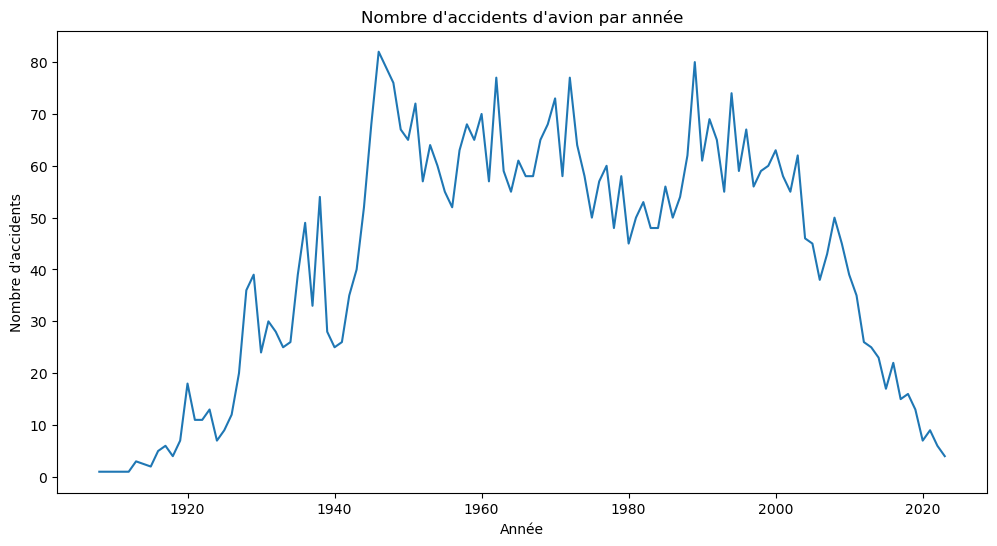

In [206]:
plt.figure(figsize=(12,6))

plt.plot(accidents_annee)

plt.title("Nombre d'accidents d'avion par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")

plt.show()

On remarque que depuis les années 2000, le nombre d'accident diminue d'année en année

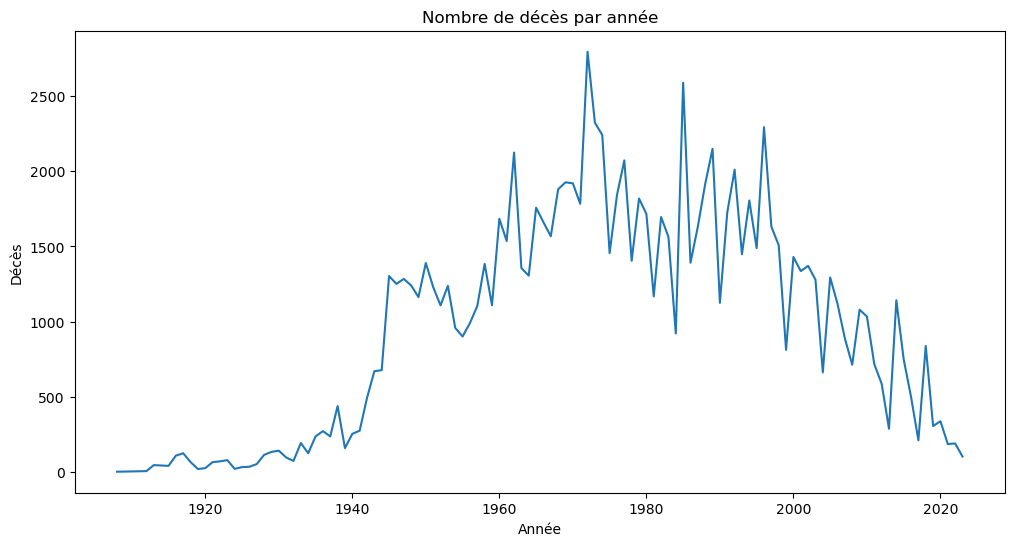

In [207]:
mort_par_annee = df_airplane.groupby('Year')['Fatalities'].sum()

plt.figure(figsize=(12,6))

plt.plot(mort_par_annee)

plt.title("Nombre de décès par année")
plt.xlabel("Année")
plt.ylabel("Décès")

plt.show()

On constate aussi que, le nombre de décès diminue au fil des années

En somme, le dataset présente une évolution historique des accidents au fil des années et le progrès de la technologie à permis de réduire ces accidents

### **3. Analyse statistique** :

In [212]:
from scipy.stats import  tmean,tstd,ttest_ind

In [209]:
mean_deaths = tmean(df_airplane['Fatalities'])
median_deaths = df_airplane['Fatalities'].median()
std_deaths =  tstd(df_airplane['Fatalities'])

print("Moyenne des décès :", mean_deaths)
print("Médiane des décès :", median_deaths)
print("Écart-type des décès :", std_deaths)

Moyenne des décès : 22.64622641509434
Médiane des décès : 11.0
Écart-type des décès : 35.38011824875092


### **Test d’hypothèse avec t-test**

Comparons les décès d'avant et après 1080, car le taux d'accidents diminuait mais à augmenter

Nous utiliserons la t-test pour notre test d'hypothèse

In [210]:
avant_1980 = df_airplane[df_airplane['Year'] < 1980]['Fatalities'].dropna()
apres_1980 = df_airplane[df_airplane['Year'] >= 1980]['Fatalities'].dropna()

La t-test se base sur la moyenne des décès

H0 : moyenne 1 == moyenne 2, on supposer alors que la moyenne des décès sont identiques

In [213]:
t_stat, p_value = ttest_ind(
    avant_1980,
    apres_1980
)

print("t-statistic :", t_stat)
print("p-value :", p_value)

t-statistic : -5.955555834053902
p-value : 2.773717328049856e-09


On constate que la p-value est extrèmement petit or le seuil alpha = 0.05, on rejette alors l'hypothèse  
2.773717328049856e-09 < 0.05  
Ce résultat indique que le nombre moyen de décès diffère significativement selon la période étudiée.

### **4. Visualisation** :

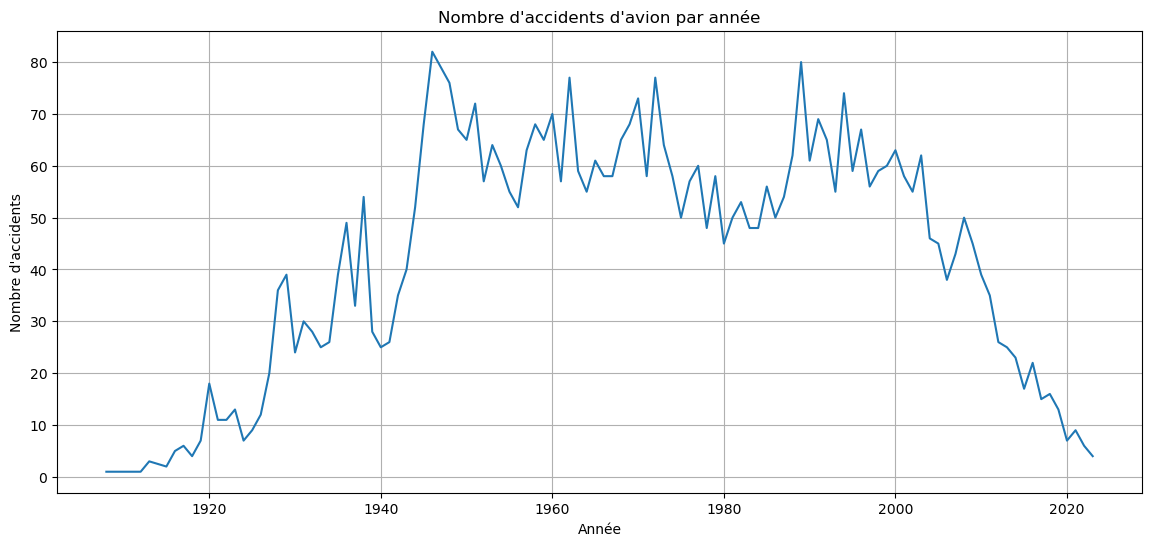

In [214]:
plt.figure(figsize=(14,6))

plt.plot(
    accidents_annee.index,
    accidents_annee.values
)

plt.title("Nombre d'accidents d'avion par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")

plt.grid(True)

plt.show()

Comme dans notre analyse précédente, on constate qu'après les années 90, le nombre d'accident diminue 

In [217]:
pays = df_airplane['Country'].value_counts().head(10)

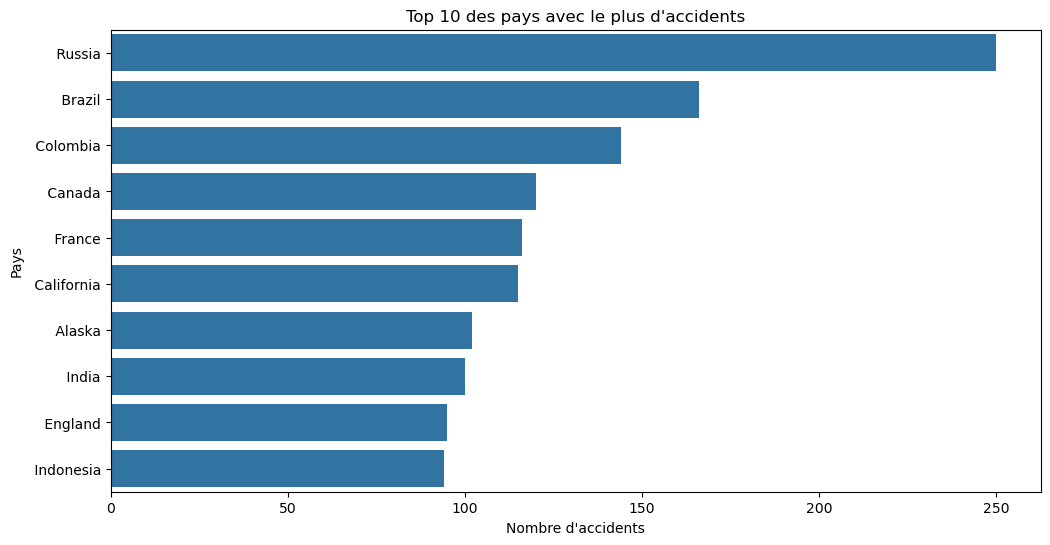

In [219]:
plt.figure(figsize=(12,6), dpi= 100)

sns.barplot(
    x=pays.values,
    y=pays.index
)

plt.title("Top 10 des pays avec le plus d'accidents")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Pays")

plt.show()

La russie est le pays ou il y a eu le plus d'accidents, environ 250. Suivie par le brésil, la colombie et le canada

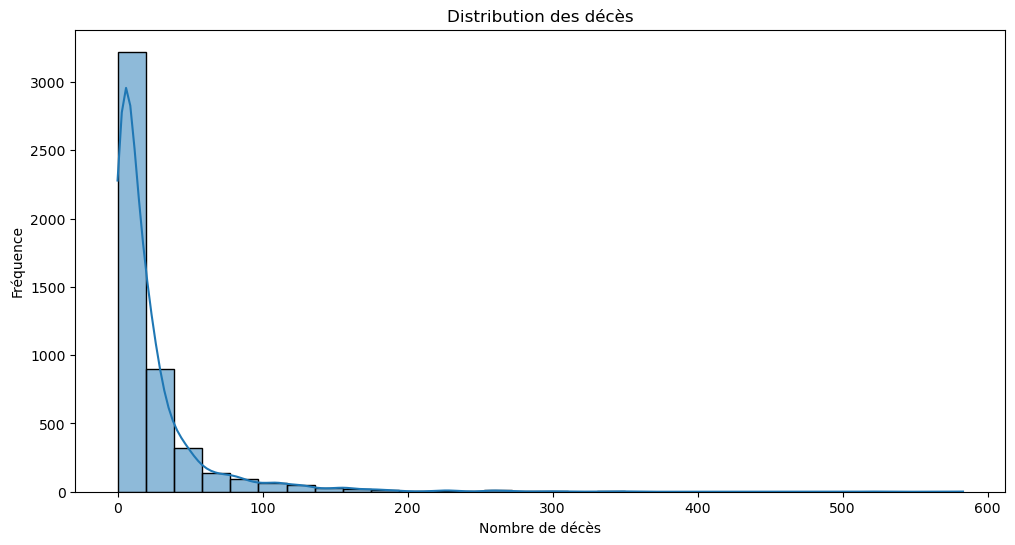

In [220]:
plt.figure(figsize=(12,6))

sns.histplot(
    df_airplane['Fatalities'],
    bins=30,
    kde=True
)

plt.title("Distribution des décès")
plt.xlabel("Nombre de décès")
plt.ylabel("Fréquence")

plt.show()

On remarque qu'on a généralement entre 0 et 20 décès lors d'un accident, cependant, les cas avec plus de 100 victimes sont plus rares

In [223]:
df_airplane['Year'].max()

np.int32(2023)

En somme, entre 1908 et 2023, il y a eu en tout 4 876 accidents d'avion et 110 423 décès lors de ces crashs, ces accidents était principalement localiser dans les zones d'amérique du sud et une bonne partie en Russie, cependant avec l'avancer de la technologie, ces accidents on commencé à baisser après les années 80